In [1]:
import pandas as pd

df = pd.read_csv("../../data/12k_all_results.csv")

In [2]:
df.columns.to_list()

['global_id',
 'sequence',
 'leah_12k_N6_1',
 'leah_12k_R6_1',
 'leah_12k_N6_2',
 'leah_12k_R6_2',
 'leah_12k_N6_3',
 'leah_12k_R6_3',
 'dna_sequence',
 'twist_dna_read_percentile',
 'leah_12k_logFC',
 'leah_12k_logCPM',
 'leah_12k_LR',
 'leah_12k_PValue',
 'leah_12k_FDR',
 'leah_12k_2fold_threshold',
 'leah_12k_Significant',
 'leah_12k_final_score',
 'leah_12k_detected',
 'leah_top10_cytotox_AUC_R_CD20',
 'leah_top10_cytotox_AUC_K_Control',
 'leah_top10_fold_change_CTV_MFI_AUC_proliferation',
 'leah_top10_cytotox_AUC_R_minus_K',
 'leah_top10_percent_cytokine_positive',
 'leah_top10_fold_change_total_cell_count_per_well_expansion',
 'leah_top10_cytotox_AUC_R_minus_K_minmax_norm',
 'leah_top10_percent_cytokine_positive_minmax_norm',
 'leah_top10_fold_change_total_cell_count_per_well_expansion_minmax_norm',
 'leah_top10_sum_of_norms',
 'leah_12k_isup',
 'leah_12k_twist_dna_detected',
 'leah_12k_2fold_threshold_int',
 'fourclass',
 'team']

In [3]:
with open("../../data/_adaptyv_selection_data/seqs_up.fasta", "w") as f:
    up_df = df[df["fourclass"] == "Up"]
    up_seqs = up_df["sequence"].tolist()
    up_ids = up_df["global_id"].tolist()
    for seq_id, seq in zip(up_ids, up_seqs):
        f.write(f">{seq_id}\n{seq}\n")

with open("../../data/_adaptyv_selection_data/seqs_down.fasta", "w") as f:
    down_df = df[df["fourclass"] == "Down"]
    down_seqs = down_df["sequence"].tolist()
    down_ids = down_df["global_id"].tolist()
    for seq_id, seq in zip(down_ids, down_seqs):
        f.write(f">{seq_id}\n{seq}\n")

with open("../../data/_adaptyv_selection_data/seqs_notsig.fasta", "w") as f:
    notsig_df = df[df["fourclass"] == "Not Sig"]
    notsig_seqs = notsig_df["sequence"].tolist()
    notsig_ids = notsig_df["global_id"].tolist()
    for seq_id, seq in zip(notsig_ids, notsig_seqs):
        f.write(f">{seq_id}\n{seq}\n")

with open("../../data/_adaptyv_selection_data/seqs_other.fasta", "w") as f:
    other_df = df[~df["fourclass"].isin(["Up", "Down", "Not Sig"])]
    other_seqs = other_df["sequence"].tolist()
    other_ids = other_df["global_id"].tolist()
    for seq_id, seq in zip(other_ids, other_seqs):
        f.write(f">{seq_id}\n{seq}\n")

now go run mmseqs on each of these

In [4]:
top_ten_df = pd.read_csv("../../data/good/master_data_top10.csv")[["global_id"]].iloc[2:].reset_index(drop=True) # remove controls
top_ten_df["global_id"] = top_ten_df["global_id"].astype(int)
final_df = top_ten_df.copy()

In [5]:
up_clusters_df = pd.read_csv("../../data/_adaptyv_selection_data/seqs_up_results_cluster.tsv", sep="\t", header=None)
up_clusters_df.columns = ["global_id", "cluster_member"]

# remove rows containing ids from final_df["global_id"]
print("Before removing final_df ids:", len(up_clusters_df))
# print("Removing rows:")
# removed_rows = up_clusters_df[up_clusters_df["cluster_member"].isin(final_df["global_id"])]
# print(removed_rows)
up_clusters_df = up_clusters_df[~up_clusters_df["global_id"].isin(final_df["global_id"])]
# print rows that were removed
print("After removing final_df ids:", len(up_clusters_df))
# randomly select 20 unique cluster members
up_clusters_df = up_clusters_df.drop_duplicates(subset=["global_id"])
up_clusters_df = up_clusters_df.sample(n=20, random_state=89348928)
final_df = pd.concat([final_df, up_clusters_df[["global_id"]]], ignore_index=True)

Before removing final_df ids: 707
After removing final_df ids: 672


In [6]:
down_clusters_df = pd.read_csv("../../data/_adaptyv_selection_data/seqs_down_results_cluster.tsv", sep="\t", header=None)
down_clusters_df.columns = ["cluster_rep", "global_id"]

# add in "final score"
down_clusters_df = down_clusters_df.merge(
    df[["global_id", "leah_12k_final_score"]], on="global_id", how="left"
).sort_values(by="leah_12k_final_score", ascending=True)

# drop duplicates in order of final score
down_clusters_df = down_clusters_df.drop_duplicates(subset=["cluster_rep"])
down_clusters_df = down_clusters_df.iloc[:10].reset_index(drop=True)

final_df = pd.concat([final_df, down_clusters_df[["global_id"]]], ignore_index=True)

In [7]:
down_clusters_df

,cluster_rep,global_id,leah_12k_final_score
0,6399,6399,-107.673438
1,3555,3555,-82.049057
2,4584,4584,-38.659601
3,11186,11186,-33.589906
4,7722,7722,-32.379679
5,2577,2577,-28.414598
6,3732,3732,-25.379714
7,11257,11257,-23.511109
8,10621,10621,-18.622482
9,472,796,-11.441519


In [8]:
# randomly sample 60 sequences from seqs_notsig_results_rep_seq.fasta
# load fasta
from Bio import SeqIO
notsig_seqs = list(SeqIO.parse("../../data/_adaptyv_selection_data/seqs_notsig_results_rep_seq.fasta", "fasta"))
notsig_ids = [int(record.id) for record in notsig_seqs]
notsig_df = pd.DataFrame({"global_id": notsig_ids})
notsig_df = notsig_df[~notsig_df["global_id"].isin(final_df["global_id"])]
notsig_df = notsig_df.sample(n=60, random_state=39389851).reset_index(drop=True)
notsig_df
final_df = pd.concat([final_df, notsig_df[["global_id"]]], ignore_index=True)

In [9]:
notsig_df

,global_id
0,7143
1,2844
2,9198
3,7122
4,3686
5,9030
6,2778
7,3332
8,2869
9,945


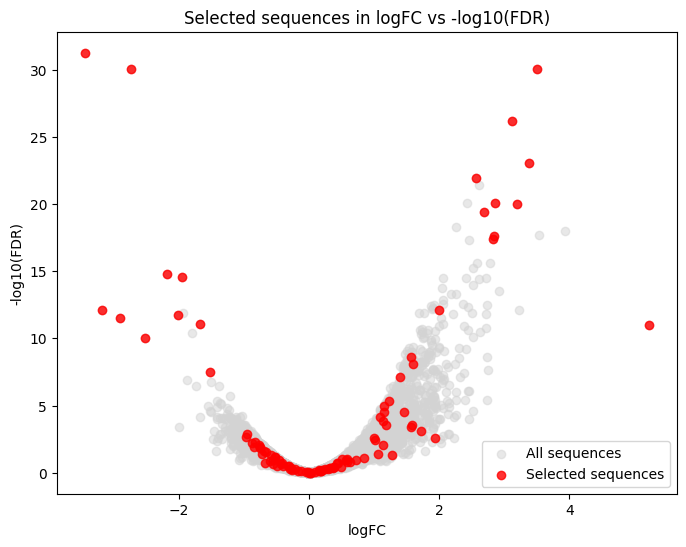

In [11]:
# merge w/ -logfdr and logfc
final_df = final_df.merge(
    df[["global_id", "sequence", "leah_12k_logFC", "leah_12k_FDR"]], on="global_id", how="left"
)

df = df.dropna(subset=["leah_12k_FDR", "leah_12k_logFC"])

# plot logFC vs -logFDR of the entire df, making sure to highlight those in final_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 6))
plt.scatter(df["leah_12k_logFC"], -np.log10(df["leah_12k_FDR"]), color="lightgray", alpha=0.5, label="All sequences")
plt.scatter(final_df["leah_12k_logFC"], -np.log10(final_df["leah_12k_FDR"]), color="red", alpha=0.8, label="Selected sequences")
plt.xlabel("logFC")
plt.ylabel("-log10(FDR)")
plt.title("Selected sequences in logFC vs -log10(FDR)")
plt.legend()
plt.show()


In [14]:
final_df["num_C"] = final_df["sequence"].str.count("C")
final_df["num_C"].value_counts()

num_C
0    72
1    11
2    11
4     2
5     2
3     2
Name: count, dtype: int64

In [19]:
final_df[["global_id", "sequence"]].to_csv("final_seqs_for_adaptyv.csv", index=False)

In [18]:
failed_ids = [
    3012,
    2014,
    2029,
    2054,
    7058,
    5089,
    2096,
    10098,
    3109,
    7122,
    7143,
    2143,
    3158,
    3165,
    11178,
    8192,
    9198,
    3229,
    7257,
    2262,
    11267,
    3275,
    2293,
    5300,
    3301,
    2328,
    3332,
    3361,
    1376,
    6399,
    3426,
    4446,
    3453,
    3494,
    8515,
    3532,
    3555,
    3558,
    2577,
    3599,
    3619,
    10621,
    5624,
    7632,
    3686,
    3714,
    3718,
    7722,
    3732,
    2754,
    2771,
    2779,
    2793,
    796,
    2844,
    2848,
    2860,
    6879,
    4885,
    1892,
    2903,
    4912,
    5932,
    10932,
    6990, # end of measured failed
    21, # start of not expressed
    3037,
    3091,
    1159,
    10173,
    3222,
    1304,
    8357,
    11364,
    8369,
    3682,
    7728,
    6867,
    2869,
    2897,
]

# count which of these ids are in up, down, notsig
up_clusters_ids = up_clusters_df["global_id"].tolist()
down_clusters_ids = down_clusters_df["global_id"].tolist()
notsig_sampled_ids = notsig_df["global_id"].tolist()

failed_up = [i for i in failed_ids if i in up_clusters_ids]
failed_down = [i for i in failed_ids if i in down_clusters_ids]
failed_notsig = [i for i in failed_ids if i in notsig_sampled_ids]

# print lens
print("Failed Up IDs:", len(failed_up), "/", len(up_clusters_ids))
print("Failed Down IDs:", len(failed_down), "/", len(down_clusters_ids))
print("Failed Not Sig IDs:", len(failed_notsig), "/", len(notsig_sampled_ids))

Failed Up IDs: 17 / 20
Failed Down IDs: 7 / 10
Failed Not Sig IDs: 49 / 60
